In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path

matches = list(
    Path("/content/drive/MyDrive").rglob("sample_dataset.csv")
)

if matches:
    DATA_PATH = str(matches[0])
    print("Dataset found:", DATA_PATH)

    if len(matches) > 1:
        print("Other matching files:")
        for path in matches[1:]:
            print(path)
else:
    raise FileNotFoundError(
        "sample_dataset.csv was not found in Google Drive. "
        "Upload it to My Drive and rerun this cell."
    )

Dataset found: /content/drive/MyDrive/sample_dataset.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

display(df.head())

Dataset loaded successfully!
Number of rows: 50000
Number of columns: 9


,Customer ID,Name,Surname,Gender,Birthdate,Transaction Amount,Date,Merchant Name,Category
0,752858,Sean,Rodriguez,F,2002-10-20,35.47,2023-04-03,Smith-Russell,Cosmetic
1,26381,Michelle,Phelps,NaN,1985-10-24,2552.72,2023-07-17,"Peck, Spence and Young",Travel
2,305449,Jacob,Williams,M,1981-10-25,115.97,2023-09-20,Steele Inc,Clothing
3,988259,Nathan,Snyder,M,1977-10-26,11.31,2023-01-11,"Wilson, Wilson and Russell",Cosmetic
4,764762,Crystal,Knapp,F,1951-11-02,62.21,2023-06-13,Palmer-Hinton,Electronics


In [ ]:
print("COLUMN NAMES:")
print(df.columns.tolist())

print("\nDATA TYPES:")
df.info()

COLUMN NAMES:
['Customer ID', 'Name', 'Surname', 'Gender', 'Birthdate', 'Transaction Amount', 'Date', 'Merchant Name', 'Category']

DATA TYPES:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer ID         50000 non-null  int64  
 1   Name                50000 non-null  object 
 2   Surname             50000 non-null  object 
 3   Gender              44953 non-null  object 
 4   Birthdate           50000 non-null  object 
 5   Transaction Amount  50000 non-null  float64
 6   Date                50000 non-null  object 
 7   Merchant Name       50000 non-null  object 
 8   Category            50000 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 3.4+ MB


In [ ]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Customer ID,50000.0,NaN,NaN,NaN,500136.79696,288232.43164,29.0,251191.5,499520.5,749854.25,999997.0
Name,50000,690,Michael,1167,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Surname,50000,1000,Smith,1095,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,44953,2,F,22713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Birthdate,50000,58,1954-11-01,914,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transaction Amount,50000.0,NaN,NaN,NaN,442.119239,631.669724,5.01,79.0075,182.195,470.515,2999.88
Date,50000,287,2023-06-30,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Merchant Name,50000,36939,Smith Ltd,69,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,50000,6,Restaurant,8413,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
quality_report = pd.DataFrame({
    "Data Type": df.dtypes.astype(str),
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().mean() * 100
    ).round(2),
    "Unique Values": df.nunique()
})

display(quality_report)

print("Exact duplicate rows:", df.duplicated().sum())

,Data Type,Missing Values,Missing Percentage,Unique Values
Customer ID,int64,0,0.00,50000
Name,object,0,0.00,690
Surname,object,0,0.00,1000
Gender,object,5047,10.09,2
Birthdate,object,0,0.00,58
Transaction Amount,float64,0,0.00,34665
Date,object,0,0.00,287
Merchant Name,object,0,0.00,36939
Category,object,0,0.00,6


Exact duplicate rows: 0


In [ ]:
df.columns = df.columns.str.strip()

df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

df["Birthdate"] = pd.to_datetime(
    df["Birthdate"],
    errors="coerce"
)

print("Transaction date range:")
print("Start:", df["Date"].min())
print("End:", df["Date"].max())

print("\nInvalid transaction dates:", df["Date"].isna().sum())
print("Invalid birthdates:", df["Birthdate"].isna().sum())

Transaction date range:
Start: 2023-01-01 00:00:00
End: 2023-10-14 00:00:00

Invalid transaction dates: 0
Invalid birthdates: 0


In [ ]:
df["Transaction Amount"] = pd.to_numeric(
    df["Transaction Amount"],
    errors="coerce"
)

print("Missing transaction amounts:",
      df["Transaction Amount"].isna().sum())

print("Zero-value transactions:",
      (df["Transaction Amount"] == 0).sum())

print("Negative-value transactions:",
      (df["Transaction Amount"] < 0).sum())

display(
    df["Transaction Amount"].describe()
)

Missing transaction amounts: 0
Zero-value transactions: 0
Negative-value transactions: 0


,Transaction Amount
count,50000.000000
mean,442.119239
std,631.669724
min,5.010000
25%,79.007500
50%,182.195000
75%,470.515000
max,2999.880000


In [ ]:
category_analysis = (
    df.groupby("Category", dropna=False)
      .agg(
          Total_Spending=("Transaction Amount", "sum"),
          Transaction_Count=("Transaction Amount", "size"),
          Average_Transaction=("Transaction Amount", "mean")
      )
      .sort_values("Total_Spending", ascending=False)
)

display(category_analysis.round(2))

,Total_Spending,Transaction_Count,Average_Transaction
Category,,,
Travel,12900231.94,8377,1539.96
Electronics,4394092.10,8324,527.88
Market,2151134.42,8382,256.64
Clothing,1319342.47,8261,159.71
Cosmetic,876672.44,8243,106.35
Restaurant,464488.60,8413,55.21


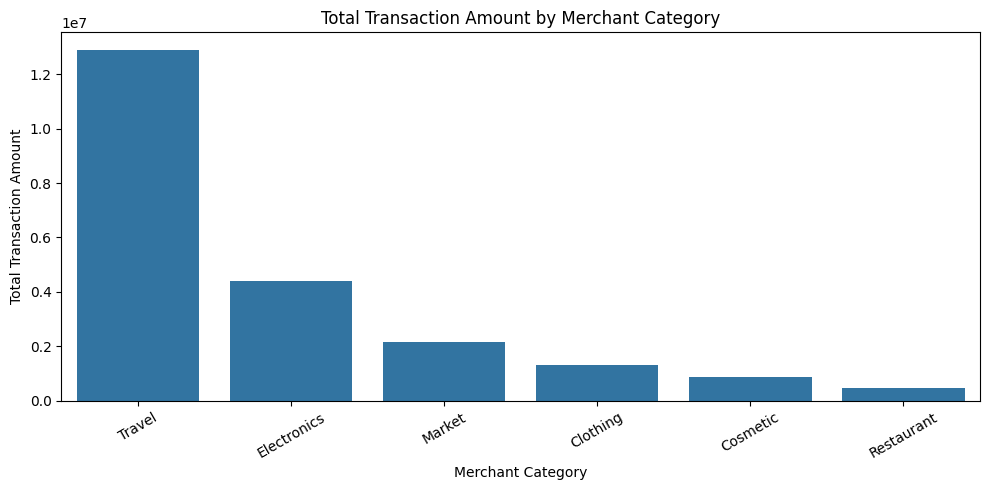

In [ ]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=category_analysis.reset_index(),
    x="Category",
    y="Total_Spending"
)

plt.title("Total Transaction Amount by Merchant Category")
plt.xlabel("Merchant Category")
plt.ylabel("Total Transaction Amount")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
df["YearMonth"] = df["Date"].dt.to_period("M").astype(str)

monthly_analysis = (
    df.groupby("YearMonth")
      .agg(
          Total_Spending=("Transaction Amount", "sum"),
          Transaction_Count=("Transaction Amount", "size"),
          Average_Transaction=("Transaction Amount", "mean")
      )
      .reset_index()
)

display(monthly_analysis.head(12))

,YearMonth,Total_Spending,Transaction_Count,Average_Transaction
0,2023-01,2345228.21,5444,430.791368
1,2023-02,2148030.95,4854,442.528008
2,2023-03,2396963.31,5456,439.326120
3,2023-04,2289731.30,5091,449.760617
4,2023-05,2460816.56,5493,447.991364
5,2023-06,2254592.41,5258,428.792775
6,2023-07,2475041.53,5458,453.470416
7,2023-08,2391450.20,5399,442.943175
8,2023-09,2274245.66,5153,441.344005
9,2023-10,1069861.84,2394,446.892999


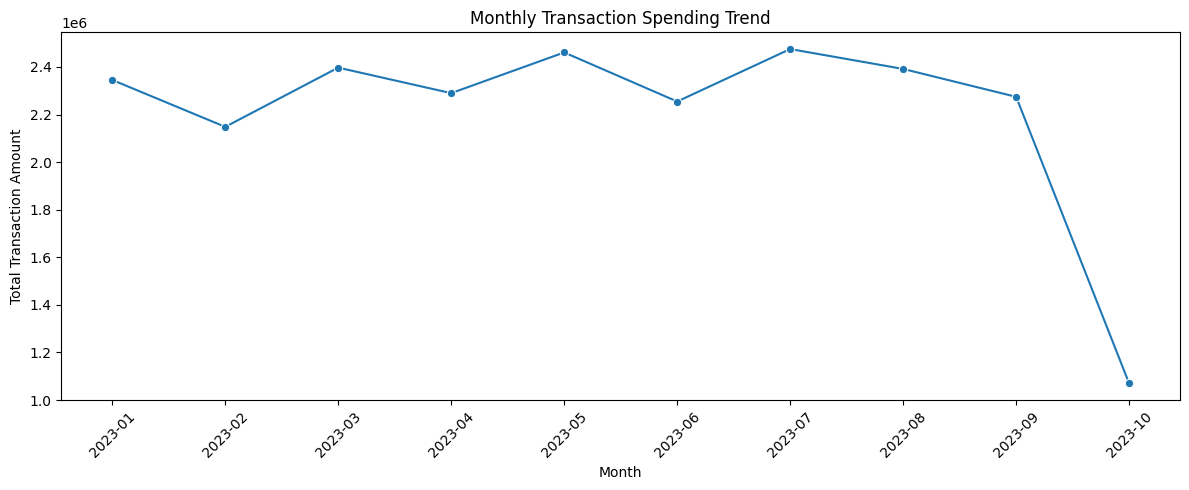

In [ ]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_analysis,
    x="YearMonth",
    y="Total_Spending",
    marker="o"
)

plt.title("Monthly Transaction Spending Trend")
plt.xlabel("Month")
plt.ylabel("Total Transaction Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df_analysis = df.copy()

# Standardize text fields
text_columns = [
    "Gender",
    "Category",
    "Merchant Name"
]

for col in text_columns:
    df_analysis[col] = df_analysis[col].astype("string").str.strip()

print("Working dataset shape:", df_analysis.shape)
print("Original dataset preserved:", df.shape)

Working dataset shape: (50000, 10)
Original dataset preserved: (50000, 10)


In [ ]:
df_analysis["Age"] = (
    df_analysis["Date"].dt.year
    - df_analysis["Birthdate"].dt.year
    - (
        (
            df_analysis["Date"].dt.month * 100
            + df_analysis["Date"].dt.day
        )
        <
        (
            df_analysis["Birthdate"].dt.month * 100
            + df_analysis["Birthdate"].dt.day
        )
    ).astype("Int64")
)

# Identify invalid or implausible ages
invalid_age = (
    df_analysis["Age"].isna()
    | (df_analysis["Age"] < 0)
    | (df_analysis["Age"] > 110)
)

print("Missing or invalid ages:", invalid_age.sum())

display(
    df_analysis.loc[invalid_age, ["Birthdate", "Date", "Age"]].head(10)
)

Missing or invalid ages: 0


,Birthdate,Date,Age


In [ ]:
age_bins = [0, 17, 24, 34, 44, 54, 64, 110]

age_labels = [
    "Under 18",
    "18-24",
    "25-34",
    "35-44",
    "45-54",
    "55-64",
    "65+"
]

df_analysis["Age Group"] = pd.cut(
    df_analysis["Age"].where(~invalid_age),
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

df_analysis["Age Group"] = (
    df_analysis["Age Group"]
    .cat.add_categories(["Unknown"])
    .fillna("Unknown")
)

print("Age group counts:")
display(df_analysis["Age Group"].value_counts().to_frame("Records"))

Age group counts:


,Records
Age Group,
65+,8709
55-64,8639
25-34,8571
35-44,8519
45-54,8517
18-24,6141
Under 18,904
Unknown,0


In [ ]:
age_analysis = (
    df_analysis.groupby("Age Group", observed=False)
    .agg(
        Total_Spending=("Transaction Amount", "sum"),
        Transaction_Count=("Transaction Amount", "count"),
        Average_Transaction=("Transaction Amount", "mean"),
        Median_Transaction=("Transaction Amount", "median")
    )
    .reset_index()
)

display(age_analysis.round(2))

,Age Group,Total_Spending,Transaction_Count,Average_Transaction,Median_Transaction
0,Under 18,402905.48,904,445.69,186.64
1,18-24,2682691.57,6141,436.85,185.11
2,25-34,3774610.59,8571,440.39,185.21
3,35-44,3729288.44,8519,437.76,181.09
4,45-54,3844808.86,8517,451.43,183.31
5,55-64,3799754.22,8639,439.84,179.88
6,65+,3871902.81,8709,444.59,180.06
7,Unknown,0.00,0,NaN,NaN


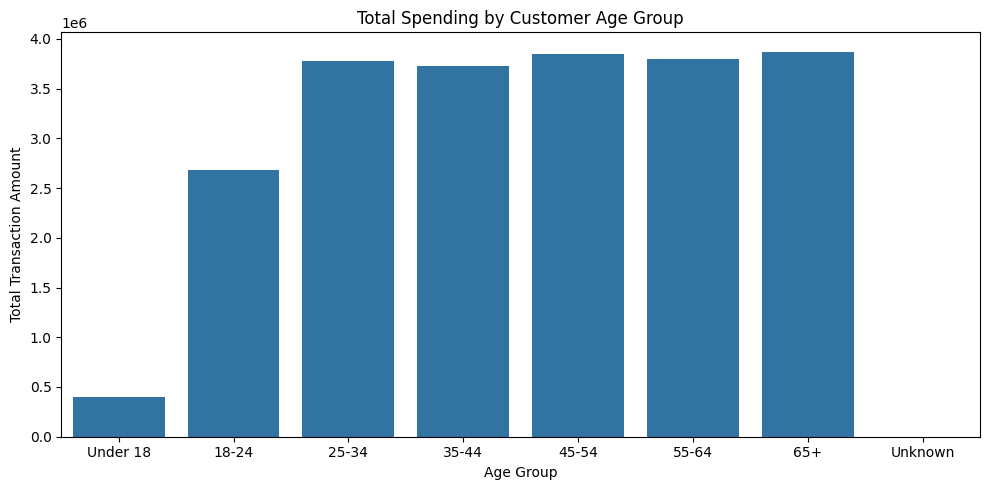

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.barplot(
    data=age_analysis[age_analysis["Age Group"] != "Unknown"],
    x="Age Group",
    y="Total_Spending"
)

plt.title("Total Spending by Customer Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Transaction Amount")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Ensure required columns exist
print(df_analysis.columns.tolist())

# Ensure transaction amounts are numeric
df_analysis["Transaction Amount"] = pd.to_numeric(
    df_analysis["Transaction Amount"],
    errors="coerce"
)

# Create spending matrix
category_age_matrix = pd.pivot_table(
    df_analysis,
    index="Age Group",
    columns="Category",
    values="Transaction Amount",
    aggfunc="sum",
    fill_value=0,
    observed=True
)

display(category_age_matrix.round(2))

['Customer ID', 'Name', 'Surname', 'Gender', 'Birthdate', 'Transaction Amount', 'Date', 'Merchant Name', 'Category', 'YearMonth', 'Age', 'Age Group']


Category,Clothing,Cosmetic,Electronics,Market,Restaurant,Travel
Age Group,,,,,,
Under 18,24168.82,14040.35,75601.62,43932.57,6881.00,238281.12
18-24,165937.74,104656.76,553258.04,260858.46,59154.03,1538826.54
25-34,238528.27,147302.35,752262.84,367462.86,80135.65,2188918.62
35-44,226150.60,146875.40,753439.31,374247.66,77023.26,2151552.21
45-54,226337.11,152828.24,723600.45,366633.53,80581.65,2294827.88
55-64,221742.04,154712.28,760318.12,359690.36,80410.22,2222881.20
65+,216477.89,156257.06,775611.72,378308.98,80302.79,2264944.37


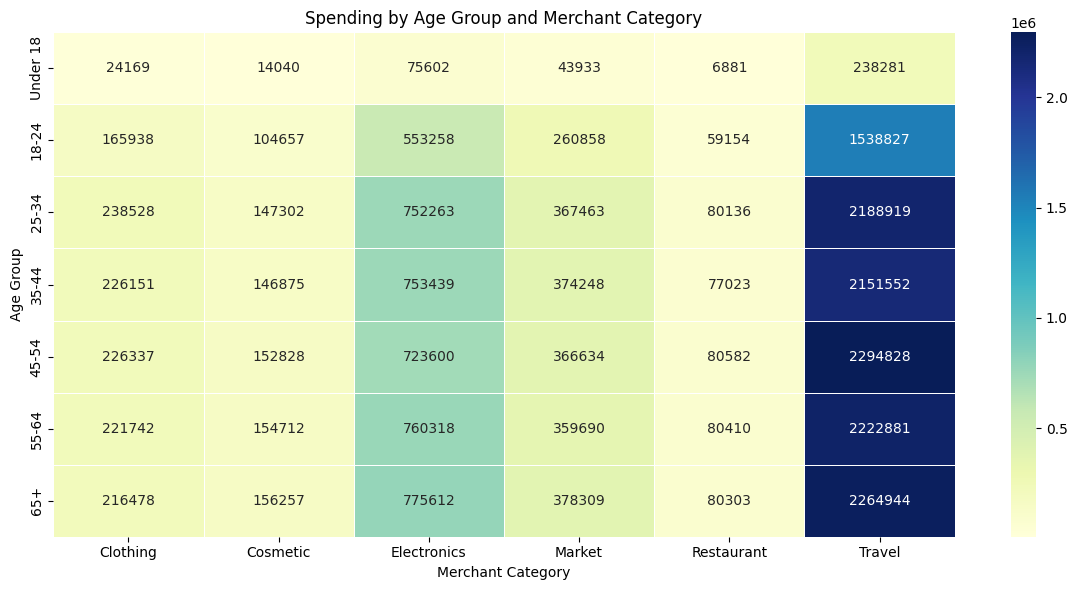

In [ ]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    category_age_matrix,
    annot=True,
    fmt=".0f",  # Format values as whole numbers
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Spending by Age Group and Merchant Category")
plt.xlabel("Merchant Category")
plt.ylabel("Age Group")
plt.tight_layout()
plt.show()

In [ ]:
monthly_analysis = (
    df_analysis.dropna(subset=["Date"])
    .groupby(pd.Grouper(key="Date", freq="MS"))
    .agg(
        Total_Spending=("Transaction Amount", "sum"),
        Transaction_Count=("Transaction Amount", "count"),
        Average_Transaction=("Transaction Amount", "mean")
    )
    .reset_index()
)

monthly_analysis["Month"] = monthly_analysis["Date"].dt.strftime("%b %Y")

display(monthly_analysis.round(2))

,Date,Total_Spending,Transaction_Count,Average_Transaction,Month
0,2023-01-01,2345228.21,5444,430.79,Jan 2023
1,2023-02-01,2148030.95,4854,442.53,Feb 2023
2,2023-03-01,2396963.31,5456,439.33,Mar 2023
3,2023-04-01,2289731.30,5091,449.76,Apr 2023
4,2023-05-01,2460816.56,5493,447.99,May 2023
5,2023-06-01,2254592.41,5258,428.79,Jun 2023
6,2023-07-01,2475041.53,5458,453.47,Jul 2023
7,2023-08-01,2391450.20,5399,442.94,Aug 2023
8,2023-09-01,2274245.66,5153,441.34,Sep 2023
9,2023-10-01,1069861.84,2394,446.89,Oct 2023


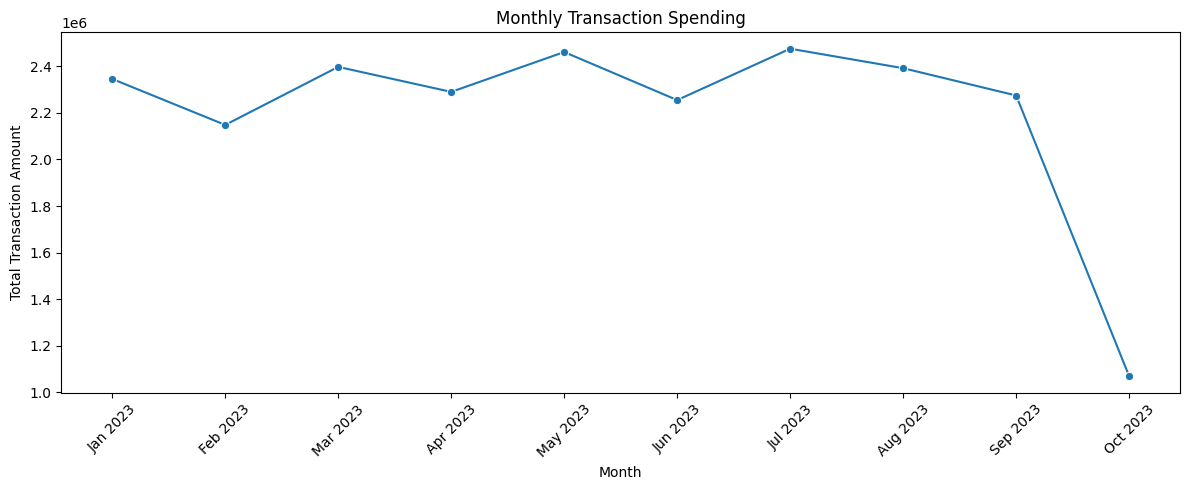

In [ ]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_analysis,
    x="Month",
    y="Total_Spending",
    marker="o"
)

plt.title("Monthly Transaction Spending")
plt.xlabel("Month")
plt.ylabel("Total Transaction Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

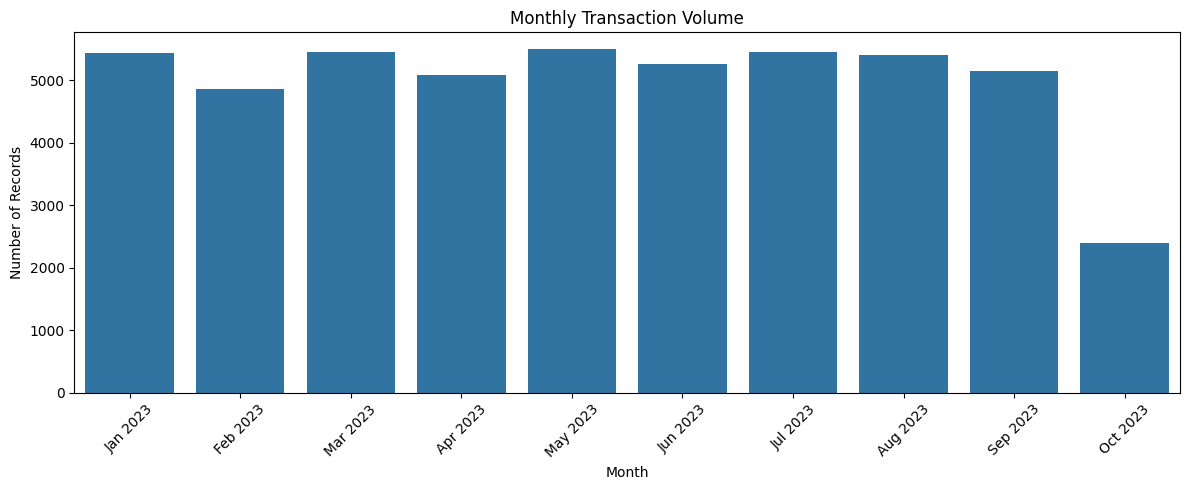

In [ ]:
plt.figure(figsize=(12, 5))

sns.barplot(
    data=monthly_analysis,
    x="Month",
    y="Transaction_Count"
)

plt.title("Monthly Transaction Volume")
plt.xlabel("Month")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
valid_amounts = df_analysis["Transaction Amount"].dropna()

total_spending = valid_amounts.sum()
transaction_count = valid_amounts.count()
average_transaction = valid_amounts.mean()
median_transaction = valid_amounts.median()
unique_customers = df_analysis["Customer ID"].nunique()
unique_merchants = df_analysis["Merchant Name"].nunique()

print("========== BANKING SPENDING KPIs ==========")
print(f"Total transaction amount: {total_spending:,.2f}")
print(f"Transaction records with valid amounts: {transaction_count:,}")
print(f"Average transaction amount: {average_transaction:,.2f}")
print(f"Median transaction amount: {median_transaction:,.2f}")
print(f"Unique customer IDs: {unique_customers:,}")
print(f"Unique merchants: {unique_merchants:,}")

========== BANKING SPENDING KPIs ==========
Total transaction amount: 22,105,961.97
Transaction records with valid amounts: 50,000
Average transaction amount: 442.12
Median transaction amount: 182.19
Unique customer IDs: 50,000
Unique merchants: 36,939


In [ ]:
gender_analysis = (
    df_analysis.groupby("Gender", dropna=False)
    .agg(
        Total_Spending=("Transaction Amount", "sum"),
        Transaction_Count=("Transaction Amount", "count"),
        Average_Transaction=("Transaction Amount", "mean"),
        Median_Transaction=("Transaction Amount", "median")
    )
    .reset_index()
    .sort_values("Total_Spending", ascending=False)
)

display(gender_analysis.round(2))

,Gender,Total_Spending,Transaction_Count,Average_Transaction,Median_Transaction
0,F,10119120.24,22713,445.52,182.05
1,M,9794882.81,22240,440.42,183.04
2,<NA>,2191958.92,5047,434.31,180.13


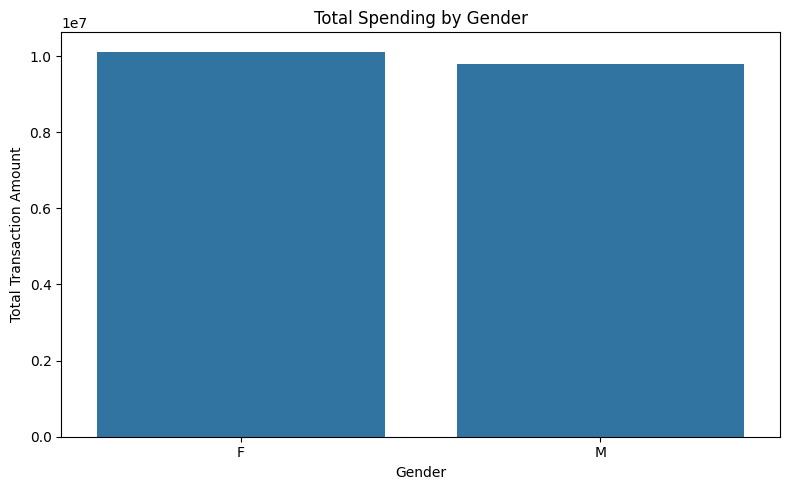

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=gender_analysis,
    x="Gender",
    y="Total_Spending"
)

plt.title("Total Spending by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Transaction Amount")
plt.tight_layout()
plt.show()

In [ ]:
merchant_analysis = (
    df_analysis.groupby("Merchant Name", dropna=False)
    .agg(
        Total_Spending=("Transaction Amount", "sum"),
        Transaction_Count=("Transaction Amount", "count"),
        Average_Transaction=("Transaction Amount", "mean")
    )
    .reset_index()
    .sort_values("Total_Spending", ascending=False)
)

display(merchant_analysis.head(10).round(2))

,Merchant Name,Total_Spending,Transaction_Count,Average_Transaction
16037,Johnson PLC,35089.71,55,637.99
30423,Smith Ltd,33304.54,69,482.67
30424,Smith PLC,30651.96,65,471.57
30421,Smith Inc,29936.92,60,498.95
16035,Johnson LLC,28670.38,53,540.95
35352,Williams LLC,27629.98,54,511.67
30422,Smith LLC,25246.87,60,420.78
30425,Smith and Sons,24695.44,56,440.99
16036,Johnson Ltd,24019.36,50,480.39
16567,Jones PLC,23873.09,35,682.09


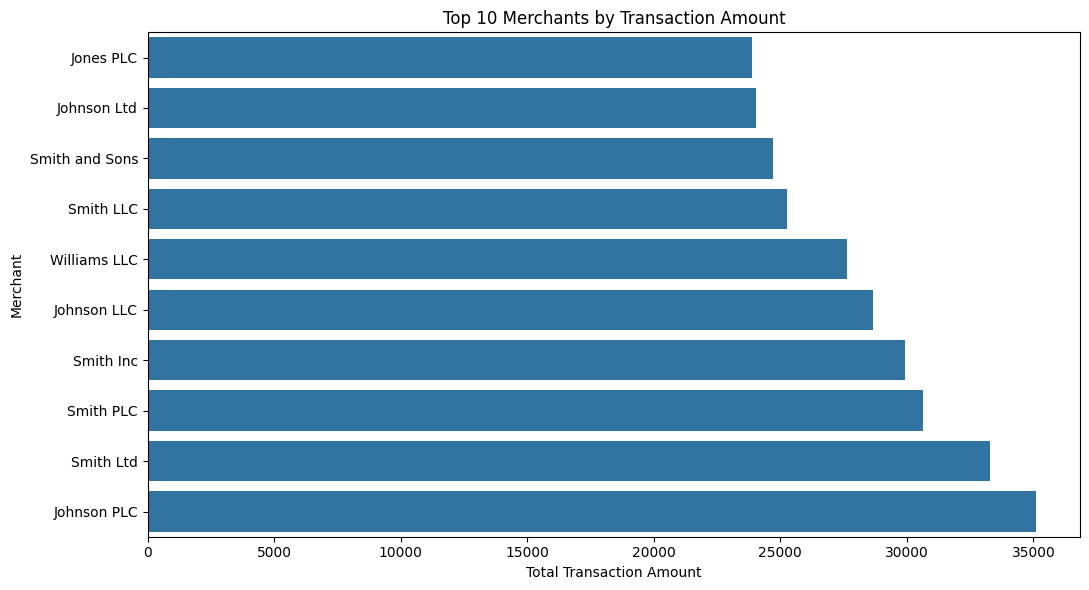

In [ ]:
top_merchants = merchant_analysis.dropna(
    subset=["Merchant Name"]
).head(10).sort_values("Total_Spending")

plt.figure(figsize=(11, 6))

sns.barplot(
    data=top_merchants,
    x="Total_Spending",
    y="Merchant Name"
)

plt.title("Top 10 Merchants by Transaction Amount")
plt.xlabel("Total Transaction Amount")
plt.ylabel("Merchant")
plt.tight_layout()
plt.show()

In [ ]:
category_summary = (
    df_analysis.groupby("Category", dropna=False)
    .agg(
        Total_Spending=("Transaction Amount", "sum"),
        Transaction_Count=("Transaction Amount", "count")
    )
    .reset_index()
)

total_category_spending = category_summary["Total_Spending"].sum()

category_summary["Spending_Share_%"] = (
    category_summary["Total_Spending"]
    / total_category_spending * 100
)

category_summary = category_summary.sort_values(
    "Total_Spending", ascending=False
)

display(category_summary.round(2))

,Category,Total_Spending,Transaction_Count,Spending_Share_%
5,Travel,12900231.94,8377,58.36
2,Electronics,4394092.10,8324,19.88
3,Market,2151134.42,8382,9.73
0,Clothing,1319342.47,8261,5.97
1,Cosmetic,876672.44,8243,3.97
4,Restaurant,464488.60,8413,2.10


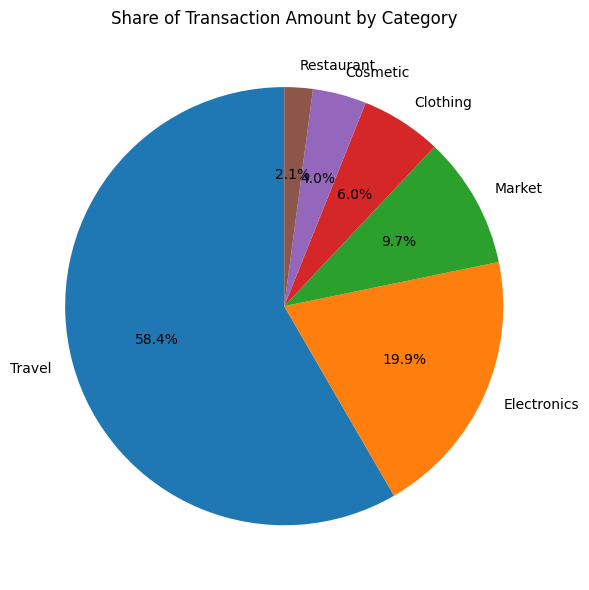

In [ ]:
category_plot = category_summary.dropna(subset=["Category"])

plt.figure(figsize=(9, 6))

plt.pie(
    category_plot["Total_Spending"],
    labels=category_plot["Category"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Share of Transaction Amount by Category")
plt.tight_layout()
plt.show()

In [ ]:
df_final = df_analysis.copy()

df_final["Year"] = df_final["Date"].dt.year
df_final["Month Number"] = df_final["Date"].dt.month
df_final["Month Name"] = df_final["Date"].dt.strftime("%B")
df_final["Quarter"] = df_final["Date"].dt.quarter

df_final["Day of Week"] = df_final["Date"].dt.day_name()

print("Final dataset shape:", df_final.shape)

display(df_final.head())

Final dataset shape: (50000, 17)


,Customer ID,Name,Surname,Gender,Birthdate,Transaction Amount,Date,Merchant Name,Category,YearMonth,Age,Age Group,Year,Month Number,Month Name,Quarter,Day of Week
0,752858,Sean,Rodriguez,F,2002-10-20,35.47,2023-04-03,Smith-Russell,Cosmetic,2023-04,20,18-24,2023,4,April,2,Monday
1,26381,Michelle,Phelps,<NA>,1985-10-24,2552.72,2023-07-17,"Peck, Spence and Young",Travel,2023-07,37,35-44,2023,7,July,3,Monday
2,305449,Jacob,Williams,M,1981-10-25,115.97,2023-09-20,Steele Inc,Clothing,2023-09,41,35-44,2023,9,September,3,Wednesday
3,988259,Nathan,Snyder,M,1977-10-26,11.31,2023-01-11,"Wilson, Wilson and Russell",Cosmetic,2023-01,45,45-54,2023,1,January,1,Wednesday
4,764762,Crystal,Knapp,F,1951-11-02,62.21,2023-06-13,Palmer-Hinton,Electronics,2023-06,71,65+,2023,6,June,2,Tuesday


In [ ]:
print("========== FINAL DATA QUALITY REPORT ==========")

print("Rows:", len(df_final))
print("Columns:", len(df_final.columns))
print("Duplicate rows:", df_final.duplicated().sum())

print("\nMissing values:")
display(
    df_final.isnull().sum()
    .to_frame("Missing Values")
    .query("`Missing Values` > 0")
)

print("\nTransaction date range:")
print(df_final["Date"].min(), "to", df_final["Date"].max())

print("\nNegative transaction amounts:",
      (df_final["Transaction Amount"] < 0).sum())

========== FINAL DATA QUALITY REPORT ==========
Rows: 50000
Columns: 17
Duplicate rows: 0

Missing values:


,Missing Values
Gender,5047



Transaction date range:
2023-01-01 00:00:00 to 2023-10-14 00:00:00

Negative transaction amounts: 0


In [ ]:
import os

OUTPUT_DIR = "/content/drive/MyDrive/Banking_Spending_Analysis"
os.makedirs(OUTPUT_DIR, exist_ok=True)

cleaned_path = os.path.join(
    OUTPUT_DIR,
    "cleaned_banking_transactions.csv"
)

df_final.to_csv(cleaned_path, index=False)

print("Cleaned dataset saved to:")
print(cleaned_path)

Cleaned dataset saved to:
/content/drive/MyDrive/Banking_Spending_Analysis/cleaned_banking_transactions.csv


In [ ]:
category_summary.to_csv(
    os.path.join(OUTPUT_DIR, "category_analysis.csv"),
    index=False
)

age_analysis.to_csv(
    os.path.join(OUTPUT_DIR, "age_group_analysis.csv"),
    index=False
)

gender_analysis.to_csv(
    os.path.join(OUTPUT_DIR, "gender_analysis.csv"),
    index=False
)

merchant_analysis.to_csv(
    os.path.join(OUTPUT_DIR, "merchant_analysis.csv"),
    index=False
)

monthly_analysis.to_csv(
    os.path.join(OUTPUT_DIR, "monthly_analysis.csv"),
    index=False
)

print("All analysis tables exported successfully!")

All analysis tables exported successfully!


In [ ]:
import os

OUTPUT_DIR = "/content/drive/MyDrive/Banking_Spending_Analysis"

for file in os.listdir(OUTPUT_DIR):
    path = os.path.join(OUTPUT_DIR, file)
    print(f"{file} — {os.path.getsize(path) / (1024 * 1024):.2f} MB")

cleaned_banking_transactions.csv — 5.70 MB
category_analysis.csv — 0.00 MB
age_group_analysis.csv — 0.00 MB
gender_analysis.csv — 0.00 MB
merchant_analysis.csv — 1.29 MB
monthly_analysis.csv — 0.00 MB
